In [14]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("../output/results")
LABELS_PATH = Path("../reference_data/penncath_hg38/penncath.csv")

## Data Setup and Simulation

In [19]:
df_labels = pd.read_csv(LABELS_PATH).set_index("ID")
print(f"labels: {df_labels.shape}")
display(df_labels.head())

labels: (1401, 6)


,CAD,sex,age,tg,hdl,ldl
ID,,,,,,
10002,1,1,60,NaN,NaN,NaN
10004,1,2,50,55.0,23.0,75.0
10005,1,1,55,105.0,37.0,69.0
10007,1,1,52,314.0,54.0,108.0
10008,1,1,58,161.0,40.0,94.0


## Data Simulation

As we don't have real EHR data, we are going to su

In [20]:
import pandas as pd
import numpy as np

def categorize_tg(val):
    if val < 150: return "LAB_TG_NORMAL"
    if val < 200: return "LAB_TG_BORDERLINE"
    return "LAB_TG_HIGH"

def categorize_hdl(val):
    return "LAB_HDL_LOW" if val < 40 else "LAB_HDL_NORMAL"

def categorize_ldl(val):
    if val < 100: return "LAB_LDL_NORMAL"
    if val < 160: return "LAB_LDL_BORDERLINE"
    return "LAB_LDL_HIGH"

def simulate_patient_trajectory(row, min_visits=3, max_visits=7, num_samples=1):
    simulated_data = []
    labels = []
    patient_id = row.name

    base_tg = row['tg'] if pd.notna(row['tg']) else np.random.normal(150, 50)
    base_hdl = row['hdl'] if pd.notna(row['hdl']) else np.random.normal(50, 15)
    base_ldl = row['ldl'] if pd.notna(row['ldl']) else np.random.normal(100, 30)

    for sample_idx in range(num_samples):
        sample_base_age = row['age'] + np.random.normal(0, 1.5)
        num_visits = np.random.randint(min_visits, max_visits + 1)
        sequence_events = []
        
        unique_sim_id = f"{patient_id}_{sample_idx}"

        for i in range(num_visits):
            years_ago = (num_visits - 1 - i) * np.random.uniform(1.0, 3.0)
            visit_age_float = sample_base_age - (num_visits - 1 - i) * np.random.uniform(0.8, 2.5)
            visit_age_int = int(round(visit_age_float))

            if row['CAD'] == 1:
                tg = base_tg - (years_ago * np.random.uniform(2, 5)) + np.random.normal(0, 5)
                hdl = base_hdl + (years_ago * np.random.uniform(0.5, 2)) + np.random.normal(0, 2)
                ldl = base_ldl - (years_ago * np.random.uniform(1, 4)) + np.random.normal(0, 5)
            else:
                tg = base_tg + np.random.normal(0, 10)
                hdl = base_hdl + np.random.normal(0, 5)
                ldl = base_ldl + np.random.normal(0, 8)

            visit_tokens = [f"[VISIT_START]", f"AGE_{visit_age_int}"]
            visit_tokens.extend([categorize_tg(tg), categorize_hdl(hdl), categorize_ldl(ldl)])

            if np.random.rand() > 1.0:
                if row['CAD'] == 1 and i == num_visits - 1:
                    visit_tokens.append("DX_I25.1")
                elif row['CAD'] == 1:
                    visit_tokens.append(np.random.choice(["DX_I10", "DX_E11", "DX_E78.5"]))
                else:
                    visit_tokens.append(np.random.choice(["DX_Z00.0", "DX_J01.9", "DX_M54.5", "DX_R51"]))

            visit_tokens.append("[VISIT_END]")
            sequence_events.append(" ".join(visit_tokens))

        full_sequence = " [SEP] ".join(sequence_events)

        simulated_data.append({
            "ID": unique_sim_id,
            "Sequence": full_sequence
        })
        
        labels.append({
            "ID": unique_sim_id,
            "CAD": int(row['CAD'])
        })

    return simulated_data, labels

def generate_ehr_datasets(df, num_samples_per_patient=3):
    all_sequences = []
    all_labels = []
    
    for _, row in df.iterrows():
        seqs, labs = simulate_patient_trajectory(row, num_samples=num_samples_per_patient)
        all_sequences.extend(seqs)
        all_labels.extend(labs)

    return pd.DataFrame(all_sequences), pd.DataFrame(all_labels)

In [21]:
df_seq, df_cad = generate_ehr_datasets(df_labels, num_samples_per_patient=20)

In [22]:
df_seq

,ID,Sequence
0,10002_0,[VISIT_START] AGE_53 LAB_TG_HIGH LAB_HDL_NORMA...
1,10002_1,[VISIT_START] AGE_53 LAB_TG_BORDERLINE LAB_HDL...
2,10002_2,[VISIT_START] AGE_57 LAB_TG_HIGH LAB_HDL_NORMA...
3,10002_3,[VISIT_START] AGE_50 LAB_TG_HIGH LAB_HDL_NORMA...
4,10002_4,[VISIT_START] AGE_54 LAB_TG_HIGH LAB_HDL_NORMA...
...,...,...
28015,11596_15,[VISIT_START] AGE_65 LAB_TG_HIGH LAB_HDL_LOW L...
28016,11596_16,[VISIT_START] AGE_57 LAB_TG_HIGH LAB_HDL_LOW L...
28017,11596_17,[VISIT_START] AGE_63 LAB_TG_HIGH LAB_HDL_LOW L...
28018,11596_18,[VISIT_START] AGE_58 LAB_TG_HIGH LAB_HDL_LOW L...


In [23]:
print(df_seq.iloc[0]['Sequence'])

[VISIT_START] AGE_53 LAB_TG_HIGH LAB_HDL_NORMAL LAB_LDL_NORMAL [VISIT_END] [SEP] [VISIT_START] AGE_52 LAB_TG_BORDERLINE LAB_HDL_NORMAL LAB_LDL_NORMAL [VISIT_END] [SEP] [VISIT_START] AGE_56 LAB_TG_BORDERLINE LAB_HDL_NORMAL LAB_LDL_NORMAL [VISIT_END] [SEP] [VISIT_START] AGE_56 LAB_TG_BORDERLINE LAB_HDL_NORMAL LAB_LDL_NORMAL [VISIT_END] [SEP] [VISIT_START] AGE_59 LAB_TG_HIGH LAB_HDL_NORMAL LAB_LDL_NORMAL [VISIT_END] [SEP] [VISIT_START] AGE_60 LAB_TG_HIGH LAB_HDL_NORMAL LAB_LDL_NORMAL [VISIT_END] [SEP] [VISIT_START] AGE_61 LAB_TG_HIGH LAB_HDL_NORMAL LAB_LDL_BORDERLINE [VISIT_END]


In [24]:
!mkdir "../reference_data/eir-transformer/"

mkdir: ../reference_data/eir-transformer/: File exists


In [25]:
from sklearn.model_selection import GroupShuffleSplit

patient_groups = df_seq['ID'].str.split('_').str[0]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_seq, groups=patient_groups))

df_seq_train = df_seq.iloc[train_idx]
df_seq_test = df_seq.iloc[test_idx]
df_cad_train = df_cad.iloc[train_idx]
df_cad_test = df_cad.iloc[test_idx]

In [26]:
from sklearn.model_selection import GroupShuffleSplit

train_patient_groups = df_seq_train['ID'].str.split('_').str[0]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)
train_idx_final, val_idx = next(gss_val.split(df_seq_train, groups=train_patient_groups))

df_seq_val = df_seq_train.iloc[val_idx]

validation_ids = df_seq_val['ID'].tolist()

with open('../reference_data/eir-transformer/validation_ids.txt', 'w') as f:
    for sample_id in validation_ids:
        f.write(f"{sample_id}\n")

In [27]:
df_seq_train.to_csv("../reference_data/eir-transformer/df_ehr.csv", index=False)
df_cad_train.to_csv("../reference_data/eir-transformer/df_cad.csv", index=False)

df_seq_test.to_csv("../reference_data/eir-transformer/df_ehr_test.csv", index=False)
df_cad_test.to_csv("../reference_data/eir-transformer/df_cad_test.csv", index=False)

# Training

In [9]:
!eirtrain --global_configs "../configs/eir-transformer/globals.yaml" --fusion_configs "../configs/eir-transformer/fusion.yaml" --output_configs "../configs/eir-transformer/output_sequence.yaml"

07:26:35 - INFO - eir.train_utils.utils - Global random seed set to 0.
07:26:35 - INFO - eir.setup.config_setup_modules.output_config_initialization - Output model type not specified in model configuration with name 'ehr', attempting to grab default value.
07:26:35 - INFO - eir.setup.streaming_data_setup.streaming_data_adapters - No streaming setup detected. Proceeding with standard data loading.
07:26:35 - INFO - eir.data_load.label_setup - Doing a manual split into validation set with 2800 IDs read from file.
07:26:35 - INFO - eir.target_setup.target_label_setup - Setting up target labels.
07:26:35 - INFO - eir.target_setup.target_label_setup - Setting up target labels for ehr.
Progress: 22400it [00:00, 6888006.57it/s]
07:26:35 - INFO - eir.target_setup.target_label_setup - Checking for missing target information. These will be ignored during loss and metric computation.
07:26:35 - INFO - eir.target_setup.target_label_setup - Output modality 'ehr' has no missing target IDs.
07:26:35 

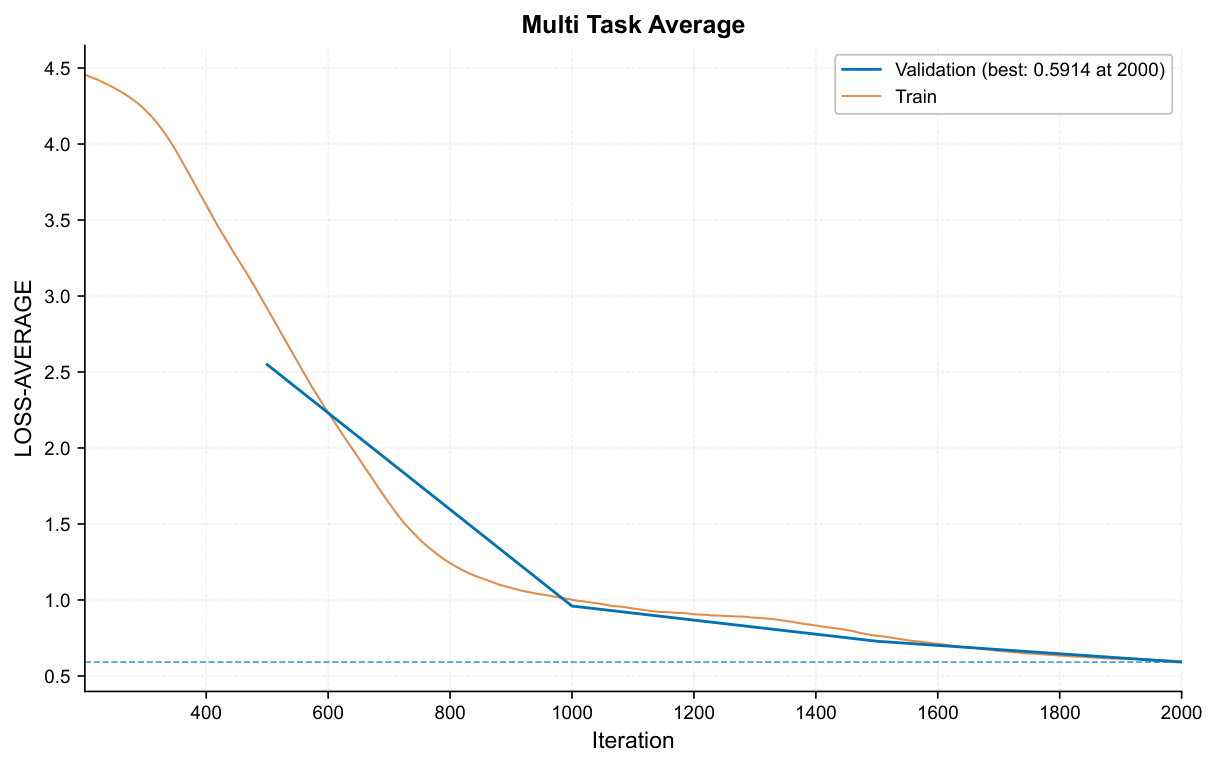

In [10]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../runs/ehr_transformer/training_curve_LOSS-AVERAGE.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

# Testing

In [11]:
!eirpredict \
    --global_configs "../configs/eir-transformer/globals.yaml" \
    --output_configs "../configs/eir-transformer/output_sequence_test.yaml" \
    --model_path "../runs/ehr_transformer/saved_models/ehr_transformer_checkpoint_2000_perf-average=0.4086.pt" \
    --evaluate \
    --output_folder "../runs/ehr_transformer/test_set_predictions"

07:34:27 - INFO - eir.train_utils.utils - Global random seed set to 0.
07:34:27 - INFO - eir.setup.config - Skipping input config name check for sequence input config (name='ehr') as it was automatically generated from a sequence output.
07:34:27 - INFO - eir.train_utils.metrics - Tabular output performance averaging functions across tasks set to averages of ['MCC', 'ROC-AUC-MACRO', 'AP-MACRO'] for categorical targets and ['1.0-LOSS', 'PCC', 'R2'] for continuous targets. These values are used to determine overall performance (using the validation set), which is used to control factors such as early stopping and LR scheduling. Other output cases (e.g. sequence generation, image generation) use 1.0-LOSS by default.
07:34:27 - DEBUG - eir.train_utils.metrics - All metrics are validation-only metrics, will skip all metric calculation for training batches.
07:34:27 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/ehr_

## Analyzing test performance

# Training with GRS as additional inputs

In [15]:
def load_trait_csv(path: Path) -> pd.Series:
  df = pd.read_csv(path).set_index("ID")
  trait = path.stem
  prob1 = [c for c in df.columns if c.endswith("Ensemble Prob 1")]
  if prob1:
      s = df[prob1[0]].rename(trait)
      s.attrs["kind"] = "binary"
      return s
  ensemble = [c for c in df.columns if re.fullmatch(rf"{re.escape(trait)} Ensemble", c)]
  if not ensemble:
      raise ValueError(f"No ensemble column found in {path.name}: {list(df.columns)}")
  s = df[ensemble[0]].rename(trait)
  s.attrs["kind"] = "continuous"
  return s

In [16]:
RESULTS_DIR

PosixPath('../output/results')

In [17]:
series_list, kinds = [], {}
for p in sorted(RESULTS_DIR.glob("*.csv")):
  s = load_trait_csv(p)
  series_list.append(s)
  kinds[s.name] = s.attrs["kind"]

df_grs = pd.concat(series_list, axis=1)
trait_kind = pd.Series(kinds, name="kind")
print(f"preds: {df_grs.shape}  continuous={(trait_kind=='continuous').sum()}  binary={(trait_kind=='binary').sum()}")

df_grs.index = df_grs.index.astype(str)

display(df_grs.head())

preds: (1401, 315)  continuous=237  binary=78


,Alanine_aminotransferase,Albumin_BIOCH,Alkaline_phosphatase,Apolipoprotein_A,Apolipoprotein_A1,Apolipoprotein_B_BIOCH,Apolipoprotein_B_METAB,Aspartate_aminotransferase,Average_Diameter_for_HDL_Particles,Average_Diameter_for_VLDL_Particles,...,Urea,VLDL_Cholesterol,Vitamin_D,Waist_circumference,Weight_ANTHRO,Weight_IMPED,White_blood_cell_leukocyte_count,Whole_body_fat_free_mass,Whole_body_fat_mass,Whole_body_water_mass
ID,,,,,,,,,,,,,,,,,,,,,
10002,22.542772,45.750916,78.095764,1.516815,1.461326,1.079866,0.920252,25.107138,9.593956,38.873093,...,5.371122,0.798058,49.158367,92.140720,80.537926,80.50510,6.893251,54.358200,26.746830,39.798134
10004,28.100965,44.744290,82.361750,1.553589,1.489705,0.935423,0.784924,26.449203,9.604637,38.699020,...,5.384340,0.621664,46.077310,88.349655,76.547020,76.31497,6.289234,52.096508,23.333853,37.992416
10005,22.484835,45.355780,90.182304,1.544894,1.473571,1.035341,0.870705,27.218803,9.558011,39.674297,...,5.420731,0.774767,50.846190,90.930590,76.097400,75.78765,6.923183,51.953293,26.081810,37.976200
10007,23.979660,45.518280,87.363420,1.639348,1.566334,1.016251,0.852204,24.755083,9.717244,38.340710,...,5.477870,0.692197,45.338993,87.590614,70.782000,70.52157,6.385489,49.508488,22.894983,36.236700
10008,26.343996,46.066658,88.195015,1.447073,1.392570,1.073851,0.893995,26.636324,9.563436,38.972090,...,5.484081,0.751684,54.548225,87.538030,78.507370,78.36777,6.650043,52.501266,23.214048,38.252075


In [28]:
import pandas as pd
import numpy as np

df_seq['base_id'] = df_seq['ID'].str.split('_').str[0]

df_expanded = df_seq[['ID', 'base_id']].merge(
    df_grs, 
    left_on='base_id', 
    right_index=True, 
    how='left'
)

numeric_cols = df_expanded.select_dtypes(include=[np.number]).columns

noise_factor = 0.01 

for col in numeric_cols:
    noise = np.random.normal(0, df_expanded[col].std() * noise_factor, size=len(df_expanded))
    df_expanded[col] = df_expanded[col] + noise

df_grs_matched = df_expanded.drop(columns=['base_id']).set_index('ID')

In [29]:
df_grs_train = df_grs_matched[df_grs_matched.index.isin(df_seq_train["ID"])]
df_grs_test = df_grs_matched[df_grs_matched.index.isin(df_seq_test["ID"])]

In [30]:
df_grs_train.to_csv("../reference_data/eir-transformer/df_grs.csv")
df_grs_test.to_csv("../reference_data/eir-transformer/df_grs_test.csv")

In [35]:
import yaml

all_columns = [
    "I21",                                       # Acute Myocardial Infarction prediction
    "I25",                                       # Chronic Ischemic Heart Disease prediction
    "Lipoprotein_A",                             
    "Apolipoprotein_B_BIOCH",                    
    "I20",                                       # Angina Pectoris prediction
    "I10",                                       # Essential Hypertension prediction
    "Clinical_LDL_Cholesterol",                  
    "E11",                                       # Type 2 Diabetes prediction
    "Total_Triglycerides",                       
    "Systolic_blood_pressure_automated_reading"  
]

config = {
    'input_info': {
        'input_source': '../reference_data/eir-transformer/df_grs.csv',
        'input_name': 'biomarker_inputs',
        'input_type': 'tabular'
    },
    'input_type_info': {
        'input_con_columns': all_columns 
    },
    'model_config': {
        'model_type': 'tabular'
    }
}

with open('../configs/eir-transformer-with-grs/input_tabular.yaml', 'w') as f:
    yaml.dump(config, f, sort_keys=False, default_flow_style=False)

In [36]:
config = {
    'input_info': {
        'input_source': '../reference_data/eir-transformer/df_grs_test.csv',
        'input_name': 'biomarker_inputs',
        'input_type': 'tabular'
    },
    'input_type_info': {
        'input_con_columns': all_columns 
    },
    'model_config': {
        'model_type': 'tabular'
    }
}

with open('../configs/eir-transformer-with-grs/input_tabular_test.yaml', 'w') as f:
    yaml.dump(config, f, sort_keys=False, default_flow_style=False)

In [33]:
!eirtrain \
    --global_configs "../configs/eir-transformer-with-grs/globals.yaml" \
    --input_configs  "../configs/eir-transformer-with-grs/input_tabular.yaml" \
    --fusion_configs "../configs/eir-transformer/fusion.yaml" \
    --output_configs "../configs/eir-transformer-with-grs/output_sequence.yaml"

07:38:44 - INFO - eir.train_utils.utils - Global random seed set to 0.
07:38:44 - INFO - eir.setup.config_setup_modules.output_config_initialization - Output model type not specified in model configuration with name 'ehr', attempting to grab default value.
07:38:44 - INFO - eir.setup.streaming_data_setup.streaming_data_adapters - No streaming setup detected. Proceeding with standard data loading.
07:38:44 - INFO - eir.data_load.label_setup - Doing a manual split into validation set with 2800 IDs read from file.
07:38:44 - INFO - eir.target_setup.target_label_setup - Setting up target labels.
07:38:44 - INFO - eir.target_setup.target_label_setup - Setting up target labels for ehr.
Progress: 22400it [00:00, 7268482.87it/s]
07:38:44 - INFO - eir.target_setup.target_label_setup - Checking for missing target information. These will be ignored during loss and metric computation.
07:38:44 - INFO - eir.target_setup.target_label_setup - Output modality 'ehr' has no missing target IDs.
07:38:44 

In [29]:
df_grs_train["I25"].describe()

count    22400.000000
mean         0.390865
std          0.064953
min          0.223707
25%          0.342785
50%          0.388148
75%          0.436151
max          0.635947
Name: I25, dtype: float64